In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats as st
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from scipy.stats import chi2_contingency
from collections import Counter
from math import sqrt

In [2]:
df = pd.read_excel(r'C:\Users\sofi\Desktop\dataticket\t2018.xlsx',sep=';', encoding = 'ISO-8859-1')

In [8]:
df

,ID_ORDER,DATE-ADD,TIME-ADD,HOUR,SEASON,P_MONTH,P_WEEK,COVID,CONFINEMENT,CURFEW,...,REGION,AREA,CLASS,TOTAL_QUANTITY,TOTAL_QUANTITY_SEGMENTS,TOTAL_TICKET,TICKET_VALUE,TOTAL_PRICE,TOTAL_REDUCTION,TOTAL_REDUCTION_PERCENT
0,66032518,2018-01-01,2018-01-01 12:06:50,Early_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,0,NaN,135.90,Entre 100 et 200 DT,41.0,-94.90,-231.463415
1,80143573,2018-01-01,2018-01-01 16:03:37,Late_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,1,1 pièce,79.90,Inférieur à 100 DT,79.9,0.00,0.000000
2,80143576,2018-01-01,2018-01-01 17:38:26,Late_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,2,2 pièces,124.85,Entre 100 et 200 DT,164.8,39.95,24.241505
3,80143572,2018-01-01,2018-01-01 14:52:08,Early_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,1,1 pièce,49.90,Inférieur à 100 DT,49.9,0.00,0.000000
4,80143574,2018-01-01,2018-01-01 16:56:04,Late_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,1,1 pièce,59.90,Inférieur à 100 DT,59.9,0.00,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235030,14142423,2018-12-31,2018-12-31 11:04:33,Late_morning,Winter,End_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,NaN,NaN,NaN,1,1 pièce,119.60,Entre 100 et 200 DT,-0.1,-119.70,119700.000000
235031,14142429,2018-12-31,2018-12-31 12:14:02,Early_afternoon,Winter,End_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,0,NaN,0.00,Inférieur à 100 DT,0.0,0.00,NaN
235032,14142426,2018-12-31,2018-12-31 11:16:19,Late_morning,Winter,End_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,0,NaN,197.80,Entre 100 et 200 DT,-10.1,-207.90,2058.415842
235033,31230584,2018-12-31,2018-12-31 15:58:52,Late_afternoon,Winter,End_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,0,NaN,20.00,Inférieur à 100 DT,20.0,0.00,0.000000


In [3]:
df2 = pd.read_excel(r'C:\Users\sofi\Desktop\dataticket\t2019.xlsx',sep=';', encoding = 'ISO-8859-1')

In [9]:
df2

,ID_ORDER,DATE-ADD,TIME-ADD,HOUR,SEASON,P_MONTH,P_WEEK,COVID,CONFINEMENT,CURFEW,...,REGION,AREA,CLASS,TOTAL_QUANTITY,TOTAL_QUANTITY_SEGMENTS,TOTAL_TICKET,TICKET_VALUE,TOTAL_PRICE,TOTAL_REDUCTION,TOTAL_REDUCTION_PERCENT
0,800155370,2019-01-01,2019-01-01 14:12:00,Early_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,2,2 pièces,89.9,Inférieur à 100 DT,159.8,69.9,43.742178
1,800155372,2019-01-01,2019-01-01 16:20:03,Late_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,2,2 pièces,89.9,Inférieur à 100 DT,149.8,59.9,39.986649
2,800155367,2019-01-01,2019-01-01 14:01:35,Early_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,2,2 pièces,189.9,Entre 100 et 200 DT,339.8,149.9,44.114185
3,800155369,2019-01-01,2019-01-01 14:07:08,Early_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,2,2 pièces,89.9,Inférieur à 100 DT,179.8,89.9,50.000000
4,800155368,2019-01-01,2019-01-01 14:06:46,Early_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,2,2 pièces,149.0,Entre 100 et 200 DT,238.0,89.0,37.394958
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
216429,660041655,2019-12-31,2019-12-31 14:42:37,Early_afternoon,Winter,End_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,centre-est,urbaine,C+,1,1 pièce,29.9,Inférieur à 100 DT,79.9,50.0,62.578223
216430,640084347,2019-12-31,2019-12-31 13:21:08,Early_afternoon,Winter,End_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,nord-est,urbaine,B,1,1 pièce,48.9,Inférieur à 100 DT,98.9,50.0,50.556117
216431,35040378,2019-12-31,2019-12-31 18:29:43,Evening,Winter,End_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,centre-ouest,urbaine,C-,2,2 pièces,24.8,Inférieur à 100 DT,74.8,50.0,66.844920
216432,63060826,2019-12-31,2019-12-31 12:49:17,Early_afternoon,Winter,End_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,A,1,1 pièce,19.9,Inférieur à 100 DT,69.9,50.0,71.530758


In [4]:
df3 = pd.read_excel(r'C:\Users\sofi\Desktop\dataticket\t2020.xlsx',sep=';', encoding = 'ISO-8859-1')

In [10]:
df3

,ID_ORDER,DATE-ADD,TIME-ADD,HOUR,SEASON,P_MONTH,P_WEEK,COVID,CONFINEMENT,CURFEW,...,REGION,AREA,CLASS,TOTAL_QUANTITY,TOTAL_QUANTITY_SEGMENTS,TOTAL_TICKET,TICKET_VALUE,TOTAL_PRICE,TOTAL_REDUCTION,TOTAL_REDUCTION_PERCENT
0,800165848,2020-01-01,2020-01-01 18:30:31,Evening,Winter,Start_of_Month,Mid_Week,Pre-Covid,NO,NO,...,Grand-Tunis,urbaine,B,2,2 pièces,249.0,Entre 200 et 300 DT,498.0,249.0,50.000000
1,800165832,2020-01-01,2020-01-01 14:40:21,Early_afternoon,Winter,Start_of_Month,Mid_Week,Pre-Covid,NO,NO,...,Grand-Tunis,urbaine,B,2,2 pièces,198.0,Entre 100 et 200 DT,337.0,139.0,41.246291
2,800165836,2020-01-01,2020-01-01 15:35:49,Late_afternoon,Winter,Start_of_Month,Mid_Week,Pre-Covid,NO,NO,...,Grand-Tunis,urbaine,B,2,2 pièces,139.0,Entre 100 et 200 DT,258.0,119.0,46.124031
3,800165842,2020-01-01,2020-01-01 16:46:52,Late_afternoon,Winter,Start_of_Month,Mid_Week,Pre-Covid,NO,NO,...,Grand-Tunis,urbaine,B,2,2 pièces,109.0,Entre 100 et 200 DT,207.9,98.9,47.570948
4,800165840,2020-01-01,2020-01-01 16:36:19,Late_afternoon,Winter,Start_of_Month,Mid_Week,Pre-Covid,NO,NO,...,Grand-Tunis,urbaine,B,2,2 pièces,139.0,Entre 100 et 200 DT,278.0,139.0,50.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161235,690039055,2020-12-31,2020-12-31 16:09:38,Late_afternoon,Winter,End_of_Month,Mid_Week,Post-Covid,NO,de 20h à 5h,...,nord-ouest,urbaine,C-,2,2 pièces,89.9,Inférieur à 100 DT,179.8,89.9,50.000000
161236,690039051,2020-12-31,2020-12-31 13:01:34,Early_afternoon,Winter,End_of_Month,Mid_Week,Post-Covid,NO,de 20h à 5h,...,nord-ouest,urbaine,C-,2,2 pièces,119.0,Entre 100 et 200 DT,208.9,89.9,43.034945
161237,690039043,2020-12-31,2020-12-31 11:02:39,Late_morning,Winter,End_of_Month,Mid_Week,Post-Covid,NO,de 20h à 5h,...,nord-ouest,urbaine,C-,2,2 pièces,37.9,Inférieur à 100 DT,75.8,37.9,50.000000
161238,690039053,2020-12-31,2020-12-31 15:43:46,Late_afternoon,Winter,End_of_Month,Mid_Week,Post-Covid,NO,de 20h à 5h,...,Grand-Tunis,urbaine,A,2,2 pièces,149.0,Entre 100 et 200 DT,258.0,109.0,42.248062


In [5]:
df4 = pd.read_excel(r'C:\Users\sofi\Desktop\dataticket\t2021.xlsx',sep=';', encoding = 'ISO-8859-1')

In [11]:
df4

,ID_ORDER,DATE-ADD,TIME-ADD,HOUR,SEASON,P_MONTH,P_WEEK,COVID,CONFINEMENT,CURFEW,...,REGION,AREA,CLASS,TOTAL_QUANTITY,TOTAL_QUANTITY_SEGMENTS,TOTAL_TICKET,TICKET_VALUE,TOTAL_PRICE,TOTAL_REDUCTION,TOTAL_REDUCTION_PERCENT
0,14154176,2021-01-01,2021-01-13 09:53:21,Late_morning,Winter,Start_of_Month,Mid_Week,Post-Covid,NO,de 20h à 5h,...,Grand-Tunis,urbaine,B,2,2 pièces,0.00,Inférieur à 100 DT,10.0,10.00,100.000000
1,16300705,2021-01-01,2021-01-12 10:27:38,Late_morning,Winter,Start_of_Month,Mid_Week,Post-Covid,NO,de 20h à 5h,...,NaN,NaN,NaN,0,NaN,159.40,Entre 100 et 200 DT,-49.1,-208.50,424.643585
2,18129947,2021-01-01,2021-01-14 08:47:46,Early_morning,Winter,Start_of_Month,Mid_Week,Post-Covid,NO,de 20h à 5h,...,nord-est,urbaine,C+,1,1 pièce,0.00,Inférieur à 100 DT,39.9,39.90,100.000000
3,35045780,2021-01-01,2021-01-04 16:22:30,Late_afternoon,Winter,Start_of_Month,Mid_Week,Post-Covid,NO,de 20h à 5h,...,NaN,NaN,NaN,0,NaN,0.00,Inférieur à 100 DT,0.0,0.00,NaN
4,36028115,2021-01-01,2021-01-11 09:14:58,Late_morning,Winter,Start_of_Month,Mid_Week,Post-Covid,NO,de 20h à 5h,...,NaN,NaN,NaN,1,1 pièce,79.00,Inférieur à 100 DT,129.0,50.00,38.759690
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87005,1300225885,2021-07-04,2021-07-04 12:27:16,Early_afternoon,Summer,Start_of_Month,Week_End,Post-Covid,NO,de 22h à 5h,...,NaN,NaN,NaN,3,Entre 3 et 5 Pièces,188.16,Entre 100 et 200 DT,268.8,80.64,30.000000
87006,1300225883,2021-07-04,2021-07-04 11:02:34,Late_morning,Summer,Start_of_Month,Week_End,Post-Covid,NO,de 22h à 5h,...,NaN,NaN,NaN,2,2 pièces,139.23,Entre 100 et 200 DT,198.9,59.67,30.000000
87007,1300225886,2021-07-04,2021-07-04 14:34:13,Early_afternoon,Summer,Start_of_Month,Week_End,Post-Covid,NO,de 22h à 5h,...,NaN,NaN,NaN,2,2 pièces,145.53,Entre 100 et 200 DT,207.9,62.37,30.000000
87008,14156247,2021-07-04,2021-07-04 15:07:42,Late_afternoon,Summer,Start_of_Month,Week_End,Post-Covid,NO,de 22h à 5h,...,nord-est,urbaine,C+,1,1 pièce,19.90,Inférieur à 100 DT,69.9,50.00,71.530758


In [105]:
frames = [df, df2, df3,df4]
result = pd.concat(frames)

In [106]:
result

,ID_ORDER,DATE-ADD,TIME-ADD,HOUR,SEASON,P_MONTH,P_WEEK,COVID,CONFINEMENT,CURFEW,...,REGION,AREA,CLASS,TOTAL_QUANTITY,TOTAL_QUANTITY_SEGMENTS,TOTAL_TICKET,TICKET_VALUE,TOTAL_PRICE,TOTAL_REDUCTION,TOTAL_REDUCTION_PERCENT
0,66032518,2018-01-01,2018-01-01 12:06:50,Early_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,0,NaN,135.90,Entre 100 et 200 DT,41.0,-94.90,-231.463415
1,80143573,2018-01-01,2018-01-01 16:03:37,Late_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,1,1 pièce,79.90,Inférieur à 100 DT,79.9,0.00,0.000000
2,80143576,2018-01-01,2018-01-01 17:38:26,Late_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,2,2 pièces,124.85,Entre 100 et 200 DT,164.8,39.95,24.241505
3,80143572,2018-01-01,2018-01-01 14:52:08,Early_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,1,1 pièce,49.90,Inférieur à 100 DT,49.9,0.00,0.000000
4,80143574,2018-01-01,2018-01-01 16:56:04,Late_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,1,1 pièce,59.90,Inférieur à 100 DT,59.9,0.00,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87005,1300225885,2021-07-04,2021-07-04 12:27:16,Early_afternoon,Summer,Start_of_Month,Week_End,Post-Covid,NO,de 22h à 5h,...,NaN,NaN,NaN,3,Entre 3 et 5 Pièces,188.16,Entre 100 et 200 DT,268.8,80.64,30.000000
87006,1300225883,2021-07-04,2021-07-04 11:02:34,Late_morning,Summer,Start_of_Month,Week_End,Post-Covid,NO,de 22h à 5h,...,NaN,NaN,NaN,2,2 pièces,139.23,Entre 100 et 200 DT,198.9,59.67,30.000000
87007,1300225886,2021-07-04,2021-07-04 14:34:13,Early_afternoon,Summer,Start_of_Month,Week_End,Post-Covid,NO,de 22h à 5h,...,NaN,NaN,NaN,2,2 pièces,145.53,Entre 100 et 200 DT,207.9,62.37,30.000000
87008,14156247,2021-07-04,2021-07-04 15:07:42,Late_afternoon,Summer,Start_of_Month,Week_End,Post-Covid,NO,de 22h à 5h,...,nord-est,urbaine,C+,1,1 pièce,19.90,Inférieur à 100 DT,69.9,50.00,71.530758


In [12]:
result.isnull().sum()

ID_ORDER                        0
DATE-ADD                        0
TIME-ADD                        0
HOUR                            0
SEASON                          0
P_MONTH                         0
P_WEEK                          0
COVID                           0
CONFINEMENT                     0
CURFEW                          0
LOCATION                        0
ID_CUSTOMER                     0
lastname                        0
firstname                  355759
CUSTOMER_DESCRIPTION       125228
gender                     356417
score                          68
BIRTHDAY                   534333
AGE                        534333
AGE_SEGMENT                534346
TELEX                      361479
EMAIL                      568615
ADRESS                     486060
POSTAL_CODE                135886
CITY                       136961
REGION                     140743
AREA                       140743
CLASS                      140743
TOTAL_QUANTITY                  0
TOTAL_QUANTITY

In [13]:
data = pd.DataFrame({'Format':['Prenom','Age','Classe','Genre','Telephone','Email'],
                     'Matches': [343960,165386,558976,343302,338240,131104]
                     
                    })

In [14]:
percentage = []
for i in range(data.shape[0]):
    pct = (data.Matches[i] /699719) * 100
    percentage.append(round(pct,2))
data['Percentage'] = percentage

In [15]:
data

,Format,Matches,Percentage
0,Prenom,343960,49.16
1,Age,165386,23.64
2,Classe,558976,79.89
3,Genre,343302,49.06
4,Telephone,338240,48.34
5,Email,131104,18.74


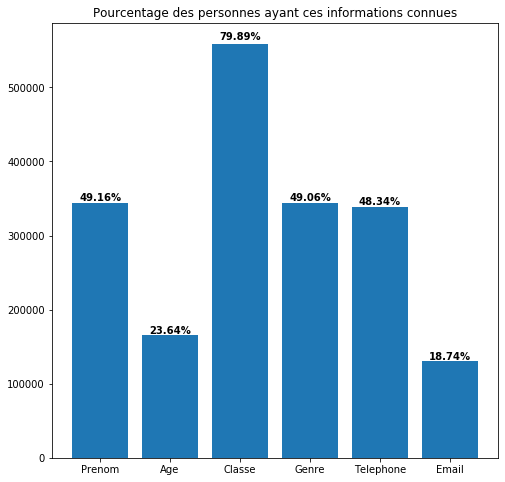

In [16]:
plt.figure(figsize=(8,8))
graph = plt.bar(data.Format,data.Matches)
plt.title('Pourcentage des personnes ayant ces informations connues')
 
i = 0
for p in graph:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    plt.text(x+width/2,
             y+height*1.01,
             str(data.Percentage[i])+'%',
             ha='center',
             weight='bold')
    i+=1
plt.show()

In [17]:
dff=result

In [22]:
dff = dff.dropna(subset=['AGE', 'gender'])

In [23]:
dff

,ID_ORDER,DATE-ADD,TIME-ADD,HOUR,SEASON,P_MONTH,P_WEEK,COVID,CONFINEMENT,CURFEW,...,REGION,AREA,CLASS,TOTAL_QUANTITY,TOTAL_QUANTITY_SEGMENTS,TOTAL_TICKET,TICKET_VALUE,TOTAL_PRICE,TOTAL_REDUCTION,TOTAL_REDUCTION_PERCENT
13,15035121,2018-01-01,2018-01-01 17:55:10,Late_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,centre-est,urbaine,C+,3,Entre 3 et 5 Pièces,179.80,Entre 100 et 200 DT,259.7,79.90,30.766269
39,16264861,2018-01-01,2018-01-01 16:37:29,Late_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,centre-est,urbaine,B,1,1 pièce,179.90,Entre 100 et 200 DT,179.9,0.00,0.000000
41,16264868,2018-01-01,2018-01-01 17:32:02,Late_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,centre-est,urbaine,C+,1,1 pièce,99.90,Inférieur à 100 DT,99.9,0.00,0.000000
97,35026888,2018-01-01,2018-01-01 16:03:51,Late_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,centre-ouest,urbaine,C-,3,Entre 3 et 5 Pièces,159.80,Entre 100 et 200 DT,216.7,56.90,26.257499
98,35026890,2018-01-01,2018-01-01 16:07:20,Late_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,centre-ouest,urbaine,C-,2,2 pièces,101.35,Entre 100 et 200 DT,133.8,32.45,24.252616
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86997,670067091,2021-07-04,2021-07-04 11:30:33,Late_morning,Summer,Start_of_Month,Week_End,Post-Covid,NO,de 22h à 5h,...,NaN,NaN,NaN,2,2 pièces,194.60,Entre 100 et 200 DT,278.0,83.40,30.000000
87000,670067090,2021-07-04,2021-07-04 10:49:45,Late_morning,Summer,Start_of_Month,Week_End,Post-Covid,NO,de 22h à 5h,...,NaN,NaN,NaN,1,1 pièce,76.30,Inférieur à 100 DT,109.0,32.70,30.000000
87001,670067095,2021-07-04,2021-07-04 17:56:33,Late_afternoon,Summer,Start_of_Month,Week_End,Post-Covid,NO,de 22h à 5h,...,sud-ouest,urbaine,B,1,1 pièce,76.30,Inférieur à 100 DT,109.0,32.70,30.000000
87008,14156247,2021-07-04,2021-07-04 15:07:42,Late_afternoon,Summer,Start_of_Month,Week_End,Post-Covid,NO,de 22h à 5h,...,nord-est,urbaine,C+,1,1 pièce,19.90,Inférieur à 100 DT,69.9,50.00,71.530758


In [24]:
dff.isnull().sum()

ID_ORDER                        0
DATE-ADD                        0
TIME-ADD                        0
HOUR                            0
SEASON                          0
P_MONTH                         0
P_WEEK                          0
COVID                           0
CONFINEMENT                     0
CURFEW                          0
LOCATION                        0
ID_CUSTOMER                     0
lastname                        0
firstname                       0
CUSTOMER_DESCRIPTION       103448
gender                          0
score                           0
BIRTHDAY                        0
AGE                             0
AGE_SEGMENT                    13
TELEX                        1672
EMAIL                       51464
ADRESS                      11332
POSTAL_CODE                 16703
CITY                        17320
REGION                      20610
AREA                        20610
CLASS                       20610
TOTAL_QUANTITY                  0
TOTAL_QUANTITY

In [25]:
data = pd.DataFrame({'Format':['Prenom','Age','Classe','Genre','Telephone','Email','Age et genre'],
                     'Matches': [343960,165386,558976,343302,338240,131104,165326]
                     
                    })

In [26]:
percentage = []
for i in range(data.shape[0]):
    pct = (data.Matches[i] /699719) * 100
    percentage.append(round(pct,2))
data['Percentage'] = percentage

In [27]:
data

,Format,Matches,Percentage
0,Prenom,343960,49.16
1,Age,165386,23.64
2,Classe,558976,79.89
3,Genre,343302,49.06
4,Telephone,338240,48.34
5,Email,131104,18.74
6,Age et genre,165326,23.63


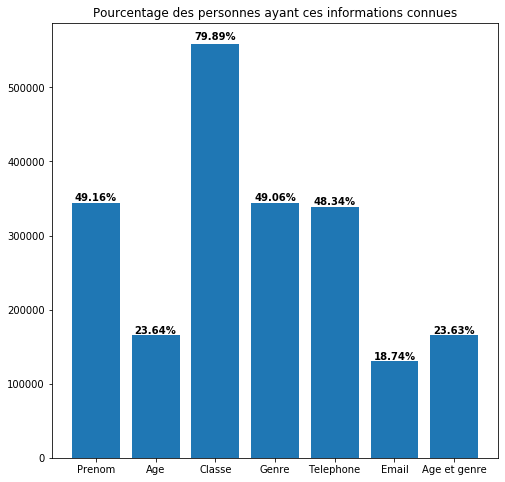

In [28]:
plt.figure(figsize=(8,8))
graph = plt.bar(data.Format,data.Matches)
plt.title('Pourcentage des personnes ayant ces informations connues')
 
i = 0
for p in graph:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    plt.text(x+width/2,
             y+height*1.01,
             str(data.Percentage[i])+'%',
             ha='center',
             weight='bold')
    i+=1
plt.show()

In [30]:
df33=df3[df3['COVID']=='Post-Covid']

In [31]:
df33

,ID_ORDER,DATE-ADD,TIME-ADD,HOUR,SEASON,P_MONTH,P_WEEK,COVID,CONFINEMENT,CURFEW,...,REGION,AREA,CLASS,TOTAL_QUANTITY,TOTAL_QUANTITY_SEGMENTS,TOTAL_TICKET,TICKET_VALUE,TOTAL_PRICE,TOTAL_REDUCTION,TOTAL_REDUCTION_PERCENT
31239,62244025,2020-03-02,2020-03-02 17:39:27,Late_afternoon,Winter,Start_of_Month,Start_of_Week,Post-Covid,NO,NO,...,Grand-Tunis,urbaine,B,0,NaN,252.84,Entre 200 et 300 DT,9.1,-243.74,-2678.461538
31240,62244022,2020-03-02,2020-03-02 17:08:50,Late_afternoon,Winter,Start_of_Month,Start_of_Week,Post-Covid,NO,NO,...,Grand-Tunis,urbaine,B,0,NaN,59.00,Inférieur à 100 DT,0.0,-59.00,-inf
31241,62244021,2020-03-02,2020-03-02 17:07:24,Late_afternoon,Winter,Start_of_Month,Start_of_Week,Post-Covid,NO,NO,...,Grand-Tunis,urbaine,B,0,NaN,69.90,Inférieur à 100 DT,0.0,-69.90,-inf
31242,690036108,2020-03-02,2020-03-02 16:06:22,Late_afternoon,Winter,Start_of_Month,Start_of_Week,Post-Covid,NO,NO,...,nord-ouest,urbaine,C-,0,NaN,301.30,Supérieur à 300 DT,10.0,-291.30,-2913.000000
31243,680068754,2020-03-02,2020-03-02 20:08:42,Evening,Winter,Start_of_Month,Start_of_Week,Post-Covid,NO,NO,...,NaN,NaN,NaN,2,2 pièces,533.00,Supérieur à 300 DT,28.9,-504.10,-1744.290657
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161235,690039055,2020-12-31,2020-12-31 16:09:38,Late_afternoon,Winter,End_of_Month,Mid_Week,Post-Covid,NO,de 20h à 5h,...,nord-ouest,urbaine,C-,2,2 pièces,89.90,Inférieur à 100 DT,179.8,89.90,50.000000
161236,690039051,2020-12-31,2020-12-31 13:01:34,Early_afternoon,Winter,End_of_Month,Mid_Week,Post-Covid,NO,de 20h à 5h,...,nord-ouest,urbaine,C-,2,2 pièces,119.00,Entre 100 et 200 DT,208.9,89.90,43.034945
161237,690039043,2020-12-31,2020-12-31 11:02:39,Late_morning,Winter,End_of_Month,Mid_Week,Post-Covid,NO,de 20h à 5h,...,nord-ouest,urbaine,C-,2,2 pièces,37.90,Inférieur à 100 DT,75.8,37.90,50.000000
161238,690039053,2020-12-31,2020-12-31 15:43:46,Late_afternoon,Winter,End_of_Month,Mid_Week,Post-Covid,NO,de 20h à 5h,...,Grand-Tunis,urbaine,A,2,2 pièces,149.00,Entre 100 et 200 DT,258.0,109.00,42.248062


In [32]:
frames = [df33, df4]
result = pd.concat(frames)

In [33]:
result

,ID_ORDER,DATE-ADD,TIME-ADD,HOUR,SEASON,P_MONTH,P_WEEK,COVID,CONFINEMENT,CURFEW,...,REGION,AREA,CLASS,TOTAL_QUANTITY,TOTAL_QUANTITY_SEGMENTS,TOTAL_TICKET,TICKET_VALUE,TOTAL_PRICE,TOTAL_REDUCTION,TOTAL_REDUCTION_PERCENT
31239,62244025,2020-03-02,2020-03-02 17:39:27,Late_afternoon,Winter,Start_of_Month,Start_of_Week,Post-Covid,NO,NO,...,Grand-Tunis,urbaine,B,0,NaN,252.84,Entre 200 et 300 DT,9.1,-243.74,-2678.461538
31240,62244022,2020-03-02,2020-03-02 17:08:50,Late_afternoon,Winter,Start_of_Month,Start_of_Week,Post-Covid,NO,NO,...,Grand-Tunis,urbaine,B,0,NaN,59.00,Inférieur à 100 DT,0.0,-59.00,-inf
31241,62244021,2020-03-02,2020-03-02 17:07:24,Late_afternoon,Winter,Start_of_Month,Start_of_Week,Post-Covid,NO,NO,...,Grand-Tunis,urbaine,B,0,NaN,69.90,Inférieur à 100 DT,0.0,-69.90,-inf
31242,690036108,2020-03-02,2020-03-02 16:06:22,Late_afternoon,Winter,Start_of_Month,Start_of_Week,Post-Covid,NO,NO,...,nord-ouest,urbaine,C-,0,NaN,301.30,Supérieur à 300 DT,10.0,-291.30,-2913.000000
31243,680068754,2020-03-02,2020-03-02 20:08:42,Evening,Winter,Start_of_Month,Start_of_Week,Post-Covid,NO,NO,...,NaN,NaN,NaN,2,2 pièces,533.00,Supérieur à 300 DT,28.9,-504.10,-1744.290657
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87005,1300225885,2021-07-04,2021-07-04 12:27:16,Early_afternoon,Summer,Start_of_Month,Week_End,Post-Covid,NO,de 22h à 5h,...,NaN,NaN,NaN,3,Entre 3 et 5 Pièces,188.16,Entre 100 et 200 DT,268.8,80.64,30.000000
87006,1300225883,2021-07-04,2021-07-04 11:02:34,Late_morning,Summer,Start_of_Month,Week_End,Post-Covid,NO,de 22h à 5h,...,NaN,NaN,NaN,2,2 pièces,139.23,Entre 100 et 200 DT,198.9,59.67,30.000000
87007,1300225886,2021-07-04,2021-07-04 14:34:13,Early_afternoon,Summer,Start_of_Month,Week_End,Post-Covid,NO,de 22h à 5h,...,NaN,NaN,NaN,2,2 pièces,145.53,Entre 100 et 200 DT,207.9,62.37,30.000000
87008,14156247,2021-07-04,2021-07-04 15:07:42,Late_afternoon,Summer,Start_of_Month,Week_End,Post-Covid,NO,de 22h à 5h,...,nord-est,urbaine,C+,1,1 pièce,19.90,Inférieur à 100 DT,69.9,50.00,71.530758


In [34]:
dfn=df[df['DATE-ADD']>='2018-03-02']

In [35]:
dfn

,ID_ORDER,DATE-ADD,TIME-ADD,HOUR,SEASON,P_MONTH,P_WEEK,COVID,CONFINEMENT,CURFEW,...,REGION,AREA,CLASS,TOTAL_QUANTITY,TOTAL_QUANTITY_SEGMENTS,TOTAL_TICKET,TICKET_VALUE,TOTAL_PRICE,TOTAL_REDUCTION,TOTAL_REDUCTION_PERCENT
45704,24158349,2018-03-02,2018-03-02 11:51:50,Late_morning,Winter,Start_of_Month,Mid_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,8,Entre 6 et 10 Pièces,302.022,Supérieur à 300 DT,639.2,337.178,52.750000
45705,24158344,2018-03-02,2018-03-02 11:29:51,Late_morning,Winter,Start_of_Month,Mid_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,2,2 pièces,80.910,Inférieur à 100 DT,179.8,98.890,55.000000
45706,24158378,2018-03-02,2018-03-02 18:18:10,Evening,Winter,Start_of_Month,Mid_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,2,2 pièces,86.292,Inférieur à 100 DT,159.8,73.508,46.000000
45707,25031288,2018-03-02,2018-03-02 12:27:15,Early_afternoon,Winter,Start_of_Month,Mid_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,4,Entre 3 et 5 Pièces,127.602,Entre 100 et 200 DT,259.6,131.998,50.846687
45708,270010893,2018-03-02,2018-03-02 17:17:45,Late_afternoon,Winter,Start_of_Month,Mid_Week,Pre-Covid,NON,NON,...,NaN,NaN,NaN,2,2 pièces,44.910,Inférieur à 100 DT,99.8,54.890,55.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235030,14142423,2018-12-31,2018-12-31 11:04:33,Late_morning,Winter,End_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,NaN,NaN,NaN,1,1 pièce,119.600,Entre 100 et 200 DT,-0.1,-119.700,119700.000000
235031,14142429,2018-12-31,2018-12-31 12:14:02,Early_afternoon,Winter,End_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,0,NaN,0.000,Inférieur à 100 DT,0.0,0.000,NaN
235032,14142426,2018-12-31,2018-12-31 11:16:19,Late_morning,Winter,End_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,0,NaN,197.800,Entre 100 et 200 DT,-10.1,-207.900,2058.415842
235033,31230584,2018-12-31,2018-12-31 15:58:52,Late_afternoon,Winter,End_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,0,NaN,20.000,Inférieur à 100 DT,20.0,0.000,0.000000


In [36]:
df22=df2[df2['DATE-ADD']<='2019-07-04']

In [37]:
df22

,ID_ORDER,DATE-ADD,TIME-ADD,HOUR,SEASON,P_MONTH,P_WEEK,COVID,CONFINEMENT,CURFEW,...,REGION,AREA,CLASS,TOTAL_QUANTITY,TOTAL_QUANTITY_SEGMENTS,TOTAL_TICKET,TICKET_VALUE,TOTAL_PRICE,TOTAL_REDUCTION,TOTAL_REDUCTION_PERCENT
0,800155370,2019-01-01,2019-01-01 14:12:00,Early_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,2,2 pièces,89.9,Inférieur à 100 DT,159.8,69.9,43.742178
1,800155372,2019-01-01,2019-01-01 16:20:03,Late_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,2,2 pièces,89.9,Inférieur à 100 DT,149.8,59.9,39.986649
2,800155367,2019-01-01,2019-01-01 14:01:35,Early_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,2,2 pièces,189.9,Entre 100 et 200 DT,339.8,149.9,44.114185
3,800155369,2019-01-01,2019-01-01 14:07:08,Early_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,2,2 pièces,89.9,Inférieur à 100 DT,179.8,89.9,50.000000
4,800155368,2019-01-01,2019-01-01 14:06:46,Early_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,2,2 pièces,149.0,Entre 100 et 200 DT,238.0,89.0,37.394958
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104530,54142515,2019-07-04,2019-07-04 16:45:22,Late_afternoon,Summer,Start_of_Month,Mid_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,0,NaN,0.0,Inférieur à 100 DT,0.0,0.0,NaN
104531,54142520,2019-07-04,2019-07-04 18:23:30,Evening,Summer,Start_of_Month,Mid_Week,Pre-Covid,NON,NON,...,nord-est,urbaine,B,1,1 pièce,98.9,Inférieur à 100 DT,98.9,0.0,0.000000
104532,51065818,2019-07-04,2019-07-04 11:18:14,Late_morning,Summer,Start_of_Month,Mid_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,0,NaN,79.1,Inférieur à 100 DT,79.1,0.0,0.000000
104533,51065823,2019-07-04,2019-07-04 20:10:50,Evening,Summer,Start_of_Month,Mid_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,1,1 pièce,59.9,Inférieur à 100 DT,59.9,0.0,0.000000


In [38]:
frames2 = [dfn, df22]
result2 = pd.concat(frames2)

In [39]:
result2

,ID_ORDER,DATE-ADD,TIME-ADD,HOUR,SEASON,P_MONTH,P_WEEK,COVID,CONFINEMENT,CURFEW,...,REGION,AREA,CLASS,TOTAL_QUANTITY,TOTAL_QUANTITY_SEGMENTS,TOTAL_TICKET,TICKET_VALUE,TOTAL_PRICE,TOTAL_REDUCTION,TOTAL_REDUCTION_PERCENT
45704,24158349,2018-03-02,2018-03-02 11:51:50,Late_morning,Winter,Start_of_Month,Mid_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,8,Entre 6 et 10 Pièces,302.022,Supérieur à 300 DT,639.2,337.178,52.750000
45705,24158344,2018-03-02,2018-03-02 11:29:51,Late_morning,Winter,Start_of_Month,Mid_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,2,2 pièces,80.910,Inférieur à 100 DT,179.8,98.890,55.000000
45706,24158378,2018-03-02,2018-03-02 18:18:10,Evening,Winter,Start_of_Month,Mid_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,2,2 pièces,86.292,Inférieur à 100 DT,159.8,73.508,46.000000
45707,25031288,2018-03-02,2018-03-02 12:27:15,Early_afternoon,Winter,Start_of_Month,Mid_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,4,Entre 3 et 5 Pièces,127.602,Entre 100 et 200 DT,259.6,131.998,50.846687
45708,270010893,2018-03-02,2018-03-02 17:17:45,Late_afternoon,Winter,Start_of_Month,Mid_Week,Pre-Covid,NON,NON,...,NaN,NaN,NaN,2,2 pièces,44.910,Inférieur à 100 DT,99.8,54.890,55.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104530,54142515,2019-07-04,2019-07-04 16:45:22,Late_afternoon,Summer,Start_of_Month,Mid_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,0,NaN,0.000,Inférieur à 100 DT,0.0,0.000,NaN
104531,54142520,2019-07-04,2019-07-04 18:23:30,Evening,Summer,Start_of_Month,Mid_Week,Pre-Covid,NON,NON,...,nord-est,urbaine,B,1,1 pièce,98.900,Inférieur à 100 DT,98.9,0.000,0.000000
104532,51065818,2019-07-04,2019-07-04 11:18:14,Late_morning,Summer,Start_of_Month,Mid_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,0,NaN,79.100,Inférieur à 100 DT,79.1,0.000,0.000000
104533,51065823,2019-07-04,2019-07-04 20:10:50,Evening,Summer,Start_of_Month,Mid_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,1,1 pièce,59.900,Inférieur à 100 DT,59.9,0.000,0.000000


In [53]:
data = pd.DataFrame({'Format':['Avant covid','Après covid'],
                     'Matches': [293866,217011]
                     
                    })

In [58]:
total = result2.loc[:, 'TOTAL_TICKET'].sum()

In [59]:
total

34640442.84620001

In [45]:
ca1=result2['TOTAL_TICKET'].sum()


In [46]:
ca1

34640442.84620001

In [47]:
ca2=result['TOTAL_TICKET'].sum()

In [48]:
ca2

25495783.3303

In [54]:
CA = [ca1,ca2]
data['Chiffre'] = CA

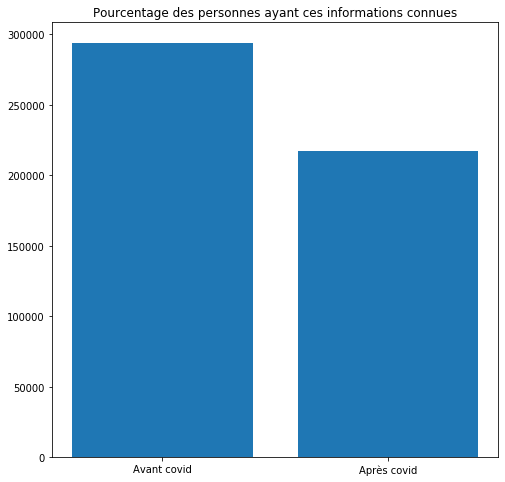

In [41]:
plt.figure(figsize=(8,8))
graph = plt.bar(data.Format,data.Matches)
plt.title('Pourcentage des personnes ayant ces informations connues')

plt.show()

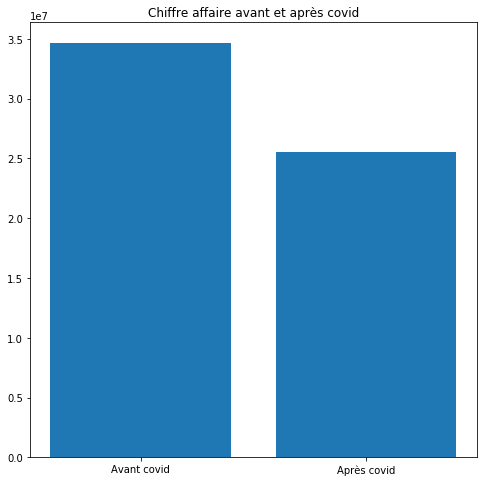

In [56]:
plt.figure(figsize=(8,8))
graph = plt.bar(data.Format,data.Chiffre)
plt.title('Chiffre affaire avant et après covid')

plt.show()

In [29]:
from statistics import stdev
from fractions import Fraction as fr

In [75]:
pip install mca

  Created wheel for mca: filename=mca-1.0.3-py2.py3-none-any.whl size=6007 sha256=97674b6e7737608a095427ab23c5f77abc0f5732be570c2581d066c743745d04
  Stored in directory: C:\Users\sofi\AppData\Local\pip\Cache\wheels\01\fb\ff\19d72d65c8bb01d4af40c9c2ca20fd267d1969b3b5f8dd60d6
Successfully built mca
Note: you may need to restart the kernel to use updated packages.


In [77]:
pip install fanalysis

Note: you may need to restart the kernel to use updated packages.


In [78]:
from fanalysis.mca import MCA

In [140]:
df_acm=pd.DataFrame(columns = ['TOTAL_TICKET','CLASS'])

In [141]:
df_acm['TOTAL_TICKET']=dff['TOTAL_TICKET']
df_acm['CLASS']=dff['CLASS']



In [142]:
dc=pd.DataFrame(pd.get_dummies(df_acm))
dc.head()

,TOTAL_TICKET,CLASS_A,CLASS_B,CLASS_C+,CLASS_C-,CLASS_D,CLASS_E
13,179.80,0,0,1,0,0,0
39,179.90,0,1,0,0,0,0
41,99.90,0,0,1,0,0,0
97,159.80,0,0,0,1,0,0
98,101.35,0,0,0,1,0,0


In [86]:
dc

,AGE_Moins de 25 ans,AGE_Plus de 50 ans,AGE_entre 25 et 30 ans,AGE_entre 30 et 35 ans,AGE_entre 35 et 40 ans,AGE_entre 40 et 50 ans,gender_femme,gender_homme,CLASS_A,CLASS_B,...,CLASS_C-,CLASS_D,CLASS_E,Region_Grand-Tunis,Region_centre-est,Region_centre-ouest,Region_nord-est,Region_nord-ouest,Region_sud-est,Region_sud-ouest
13,1,0,0,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
39,0,0,0,0,0,1,1,0,0,1,...,0,0,0,0,1,0,0,0,0,0
41,0,0,0,0,0,1,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
97,0,0,1,0,0,0,0,1,0,0,...,1,0,0,0,0,1,0,0,0,0
98,0,0,1,0,0,0,1,0,0,0,...,1,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86997,0,0,0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
87000,0,0,0,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
87001,0,0,0,1,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,1
87008,0,0,0,1,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [143]:
X = df_acm.iloc[:, 0:4].to_numpy()
X = X.astype(str)

In [144]:
X


array([['179.8', 'C+'],
       ['179.9', 'B'],
       ['99.9', 'C+'],
       ...,
       ['76.3', 'B'],
       ['19.9', 'C+'],
       ['9.9', 'B']], dtype='<U22')

In [145]:
my_mca = MCA(row_labels=df_acm.index.values, var_labels=df_acm.columns.values)

In [147]:
my_mca.fit(X)


MemoryError: 

In [135]:
print(my_mca.eig_)

[[5.01846433e-01 4.87788346e-01 4.12982388e-01 3.41241189e-01
  2.84505201e-01 2.62150601e-01 2.55594600e-01 2.52898550e-01
  2.52108852e-01 2.49947822e-01 2.49860620e-01 2.47794333e-01
  2.47299123e-01 2.45999570e-01 2.40413930e-01 2.31839170e-01
  2.20484804e-01 1.61334603e-01 8.96988150e-02 1.42110520e-02
  5.60608776e-26]
 [9.55897968e+00 9.29120659e+00 7.86633120e+00 6.49983217e+00
  5.41914668e+00 4.99334478e+00 4.86846857e+00 4.81711524e+00
  4.80207337e+00 4.76091089e+00 4.75924991e+00 4.71989205e+00
  4.71045948e+00 4.68570609e+00 4.57931295e+00 4.41598418e+00
  4.19971055e+00 3.07304005e+00 1.70854886e+00 2.70686705e-01
  1.06782624e-24]
 [9.55897968e+00 1.88501863e+01 2.67165175e+01 3.32163496e+01
  3.86354963e+01 4.36288411e+01 4.84973097e+01 5.33144249e+01
  5.81164983e+01 6.28774092e+01 6.76366591e+01 7.23565511e+01
  7.70670106e+01 8.17527167e+01 8.63320297e+01 9.07480138e+01
  9.49477244e+01 9.80207644e+01 9.97293133e+01 1.00000000e+02
  1.00000000e+02]]


In [136]:
df_cols = my_mca.col_topandas()
print(df_cols)

                     col_coord_dim1  col_coord_dim2  col_coord_dim3  \
AGE_1.0                   -0.114133        0.031402        0.236526   
AGE_2.0                   -0.051598        0.156897        0.291661   
AGE_3.0                    0.028042        0.096983        0.111875   
AGE_4.0                    0.058497       -0.042995        0.036122   
AGE_5.0                    0.065994        0.001333       -0.001401   
AGE_6.0                   -0.175529       -0.129395       -0.372566   
AGE_nan                   -4.365816        0.156096       -0.040839   
gender_1.0                -0.052679       -0.073851        0.042593   
gender_2.0                 0.082984        0.114134       -0.065278   
gender_nan                -1.638222        0.086127       -0.642569   
CLASS_A                    0.313455       -0.624905       -2.217780   
CLASS_B                    0.334075       -0.516734       -0.257862   
CLASS_C+                   0.359122       -0.379183        1.247745   
CLASS_

In [137]:
df_rows = my_mca.col_topandas()
print(df_rows)

                     col_coord_dim1  col_coord_dim2  col_coord_dim3  \
AGE_1.0                   -0.114133        0.031402        0.236526   
AGE_2.0                   -0.051598        0.156897        0.291661   
AGE_3.0                    0.028042        0.096983        0.111875   
AGE_4.0                    0.058497       -0.042995        0.036122   
AGE_5.0                    0.065994        0.001333       -0.001401   
AGE_6.0                   -0.175529       -0.129395       -0.372566   
AGE_nan                   -4.365816        0.156096       -0.040839   
gender_1.0                -0.052679       -0.073851        0.042593   
gender_2.0                 0.082984        0.114134       -0.065278   
gender_nan                -1.638222        0.086127       -0.642569   
CLASS_A                    0.313455       -0.624905       -2.217780   
CLASS_B                    0.334075       -0.516734       -0.257862   
CLASS_C+                   0.359122       -0.379183        1.247745   
CLASS_

In [149]:
# Mapping des points colonnes
my_mca.mapping_col(num_x_axis=1, num_y_axis=2, figsize=(7, 7))

AttributeError: 'MCA' object has no attribute 'model_'

<Figure size 504x504 with 0 Axes>

In [74]:
corr=dff.corr()
corr

,ID_ORDER,score,AGE,TOTAL_QUANTITY,TOTAL_TICKET,TOTAL_PRICE,TOTAL_REDUCTION,TOTAL_REDUCTION_PERCENT
ID_ORDER,1.000000,0.024441,-0.018311,-0.006149,-0.017485,-0.005222,0.006888,-0.003664
score,0.024441,1.000000,-0.016561,0.002402,0.002194,0.004583,0.005721,-0.001484
AGE,-0.018311,-0.016561,1.000000,0.019192,0.021630,0.027713,0.027113,-0.000609
TOTAL_QUANTITY,-0.006149,0.002402,0.019192,1.000000,0.691813,0.826562,0.766877,0.001961
TOTAL_TICKET,-0.017485,0.002194,0.021630,0.691813,1.000000,0.870481,0.564780,-0.006587
TOTAL_PRICE,-0.005222,0.004583,0.027713,0.826562,0.870481,1.000000,0.897816,0.001719
TOTAL_REDUCTION,0.006888,0.005721,0.027113,0.766877,0.564780,0.897816,1.000000,0.008952
TOTAL_REDUCTION_PERCENT,-0.003664,-0.001484,-0.000609,0.001961,-0.006587,0.001719,0.008952,1.000000


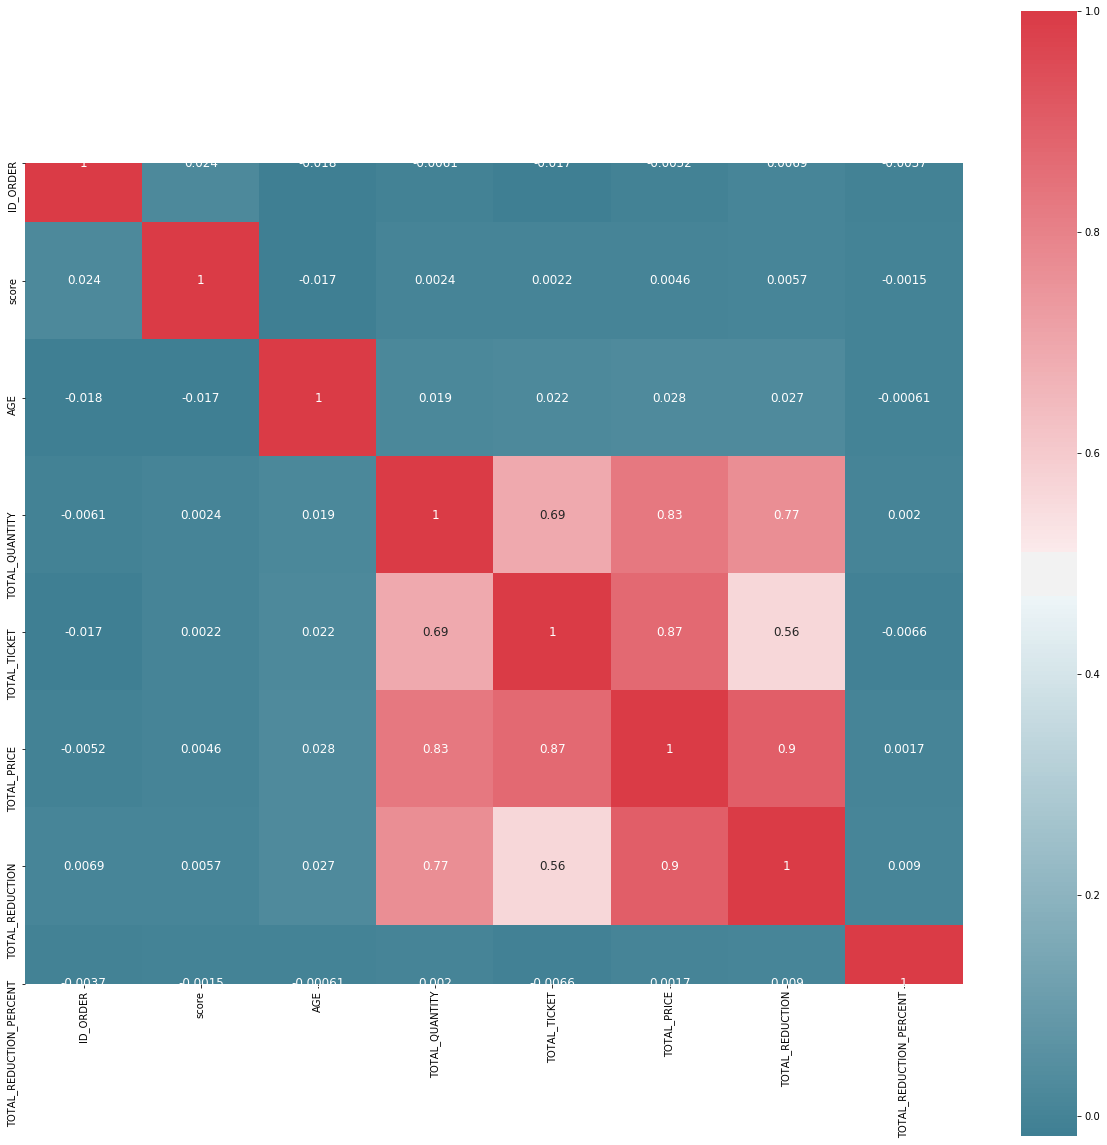

In [97]:
#Correlation Map

def plot_correlation_map( df ):

    corr = df.corr()
    s , ax = plt.subplots( figsize =( 21 , 23) )
    cmap = sns.diverging_palette( 220 , 10 , as_cmap = True )
    s = sns.heatmap(corr,cmap = cmap,square=True, cbar_kws={ 'shrink' : .9 }, ax=ax, annot = True, annot_kws = 
                    { 'fontsize' : 12 } )
    

plot_correlation_map(dff)

Text(0.5, 1, 'Correlation Heatmap')

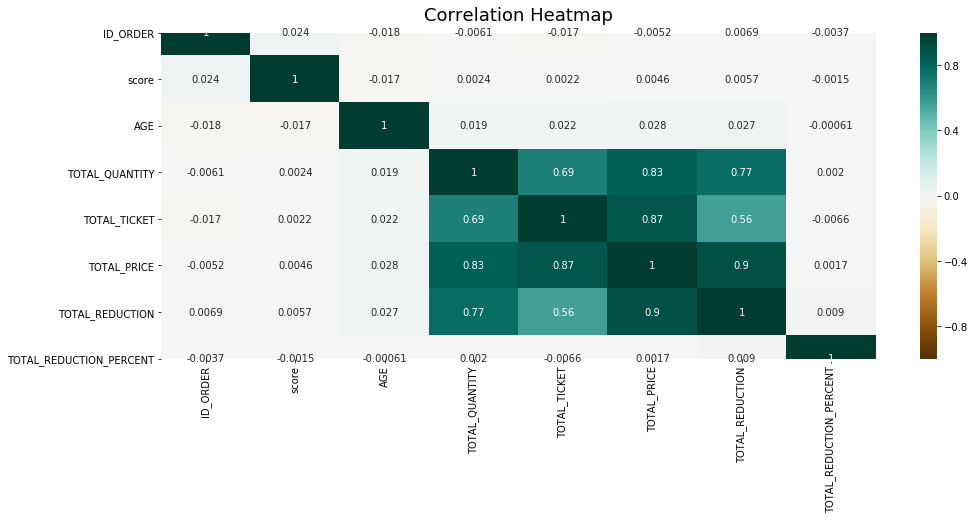

In [98]:
plt.figure(figsize=(16, 6))
heatmap = sns.heatmap(dff.corr(), vmin=-1, vmax=1, annot=True, cmap='BrBG')
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':18}, pad=12)

In [99]:
dff

,ID_ORDER,DATE-ADD,TIME-ADD,HOUR,SEASON,P_MONTH,P_WEEK,COVID,CONFINEMENT,CURFEW,...,REGION,AREA,CLASS,TOTAL_QUANTITY,TOTAL_QUANTITY_SEGMENTS,TOTAL_TICKET,TICKET_VALUE,TOTAL_PRICE,TOTAL_REDUCTION,TOTAL_REDUCTION_PERCENT
13,15035121,2018-01-01,2018-01-01 17:55:10,Late_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,centre-est,urbaine,C+,3,Entre 3 et 5 Pièces,179.80,Entre 100 et 200 DT,259.7,79.90,30.766269
39,16264861,2018-01-01,2018-01-01 16:37:29,Late_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,centre-est,urbaine,B,1,1 pièce,179.90,Entre 100 et 200 DT,179.9,0.00,0.000000
41,16264868,2018-01-01,2018-01-01 17:32:02,Late_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,centre-est,urbaine,C+,1,1 pièce,99.90,Inférieur à 100 DT,99.9,0.00,0.000000
97,35026888,2018-01-01,2018-01-01 16:03:51,Late_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,centre-ouest,urbaine,C-,3,Entre 3 et 5 Pièces,159.80,Entre 100 et 200 DT,216.7,56.90,26.257499
98,35026890,2018-01-01,2018-01-01 16:07:20,Late_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,centre-ouest,urbaine,C-,2,2 pièces,101.35,Entre 100 et 200 DT,133.8,32.45,24.252616
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86997,670067091,2021-07-04,2021-07-04 11:30:33,Late_morning,Summer,Start_of_Month,Week_End,Post-Covid,NO,de 22h à 5h,...,NaN,NaN,NaN,2,2 pièces,194.60,Entre 100 et 200 DT,278.0,83.40,30.000000
87000,670067090,2021-07-04,2021-07-04 10:49:45,Late_morning,Summer,Start_of_Month,Week_End,Post-Covid,NO,de 22h à 5h,...,NaN,NaN,NaN,1,1 pièce,76.30,Inférieur à 100 DT,109.0,32.70,30.000000
87001,670067095,2021-07-04,2021-07-04 17:56:33,Late_afternoon,Summer,Start_of_Month,Week_End,Post-Covid,NO,de 22h à 5h,...,sud-ouest,urbaine,B,1,1 pièce,76.30,Inférieur à 100 DT,109.0,32.70,30.000000
87008,14156247,2021-07-04,2021-07-04 15:07:42,Late_afternoon,Summer,Start_of_Month,Week_End,Post-Covid,NO,de 22h à 5h,...,nord-est,urbaine,C+,1,1 pièce,19.90,Inférieur à 100 DT,69.9,50.00,71.530758


In [104]:
dff

,ID_ORDER,DATE-ADD,TIME-ADD,HOUR,SEASON,P_MONTH,P_WEEK,COVID,CONFINEMENT,CURFEW,...,TICKET_VALUE,TOTAL_PRICE,TOTAL_REDUCTION,TOTAL_REDUCTION_PERCENT,Moins de 25 ans,Plus de 50 ans,entre 25 et 30 ans,entre 30 et 35 ans,entre 35 et 40 ans,entre 40 et 50 ans
1,16300705,2021-01-01,2021-01-12 10:27:38,Late_morning,Winter,Start_of_Month,Mid_Week,Post-Covid,NO,de 20h à 5h,...,Entre 100 et 200 DT,-49.1,-208.5,424.643585,0,0,0,0,1,0
2,18129947,2021-01-01,2021-01-14 08:47:46,Early_morning,Winter,Start_of_Month,Mid_Week,Post-Covid,NO,de 20h à 5h,...,Inférieur à 100 DT,39.9,39.9,100.000000,1,0,0,0,0,0
5,54151017,2021-01-01,2021-01-12 10:42:00,Late_morning,Winter,Start_of_Month,Mid_Week,Post-Covid,NO,de 20h à 5h,...,Inférieur à 100 DT,49.9,49.9,100.000000,0,1,0,0,0,0
10,40053316,2021-01-01,2021-01-14 09:16:58,Late_morning,Winter,Start_of_Month,Mid_Week,Post-Covid,NO,de 20h à 5h,...,Inférieur à 100 DT,128.0,59.0,46.093750,0,0,0,0,0,1
13,15035121,2018-01-01,2018-01-01 17:55:10,Late_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,Entre 100 et 200 DT,259.7,79.9,30.766269,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235002,1300209767,2018-12-31,2018-12-31 13:20:56,Early_afternoon,Winter,End_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,Entre 100 et 200 DT,338.0,169.0,50.000000,0,0,0,0,0,1
235011,680059844,2018-12-31,2018-12-31 18:07:02,Evening,Winter,End_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,Inférieur à 100 DT,69.9,50.0,71.530758,0,0,0,0,1,0
235012,35034106,2018-12-31,2018-12-31 19:12:45,Evening,Winter,End_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,Inférieur à 100 DT,22.9,20.0,87.336245,0,0,1,0,0,0
235013,56158345,2018-12-31,2018-12-31 17:42:20,Late_afternoon,Winter,End_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,Inférieur à 100 DT,79.9,50.0,62.578223,0,0,0,1,0,0


In [108]:
dff=result
dff

,ID_ORDER,DATE-ADD,TIME-ADD,HOUR,SEASON,P_MONTH,P_WEEK,COVID,CONFINEMENT,CURFEW,...,REGION,AREA,CLASS,TOTAL_QUANTITY,TOTAL_QUANTITY_SEGMENTS,TOTAL_TICKET,TICKET_VALUE,TOTAL_PRICE,TOTAL_REDUCTION,TOTAL_REDUCTION_PERCENT
0,66032518,2018-01-01,2018-01-01 12:06:50,Early_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,0,NaN,135.90,Entre 100 et 200 DT,41.0,-94.90,-231.463415
1,80143573,2018-01-01,2018-01-01 16:03:37,Late_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,1,1 pièce,79.90,Inférieur à 100 DT,79.9,0.00,0.000000
2,80143576,2018-01-01,2018-01-01 17:38:26,Late_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,2,2 pièces,124.85,Entre 100 et 200 DT,164.8,39.95,24.241505
3,80143572,2018-01-01,2018-01-01 14:52:08,Early_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,1,1 pièce,49.90,Inférieur à 100 DT,49.9,0.00,0.000000
4,80143574,2018-01-01,2018-01-01 16:56:04,Late_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,1,1 pièce,59.90,Inférieur à 100 DT,59.9,0.00,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87005,1300225885,2021-07-04,2021-07-04 12:27:16,Early_afternoon,Summer,Start_of_Month,Week_End,Post-Covid,NO,de 22h à 5h,...,NaN,NaN,NaN,3,Entre 3 et 5 Pièces,188.16,Entre 100 et 200 DT,268.8,80.64,30.000000
87006,1300225883,2021-07-04,2021-07-04 11:02:34,Late_morning,Summer,Start_of_Month,Week_End,Post-Covid,NO,de 22h à 5h,...,NaN,NaN,NaN,2,2 pièces,139.23,Entre 100 et 200 DT,198.9,59.67,30.000000
87007,1300225886,2021-07-04,2021-07-04 14:34:13,Early_afternoon,Summer,Start_of_Month,Week_End,Post-Covid,NO,de 22h à 5h,...,NaN,NaN,NaN,2,2 pièces,145.53,Entre 100 et 200 DT,207.9,62.37,30.000000
87008,14156247,2021-07-04,2021-07-04 15:07:42,Late_afternoon,Summer,Start_of_Month,Week_End,Post-Covid,NO,de 22h à 5h,...,nord-est,urbaine,C+,1,1 pièce,19.90,Inférieur à 100 DT,69.9,50.00,71.530758


In [115]:
dff['AGE_SEGMENT'].replace({'Moins de 25 ans': 1},inplace=True)

In [117]:
dff['AGE_SEGMENT'].replace({'entre 25 et 30 ans': 2},inplace=True)
dff['AGE_SEGMENT'].replace({'entre 30 et 35 ans': 3},inplace=True)
dff['AGE_SEGMENT'].replace({'entre 35 et 40 ans': 4},inplace=True)
dff['AGE_SEGMENT'].replace({'entre 40 et 50 ans': 5},inplace=True)
dff['AGE_SEGMENT'].replace({'Plus de 50 ans': 6},inplace=True)

In [118]:
dff['AGE_SEGMENT'].value_counts()


5.0    55480
4.0    35681
6.0    27094
3.0    24708
2.0    14853
1.0     7557
Name: AGE_SEGMENT, dtype: int64

In [120]:
dff = dff.dropna(subset=['AGE'])

In [122]:
dff


,ID_ORDER,DATE-ADD,TIME-ADD,HOUR,SEASON,P_MONTH,P_WEEK,COVID,CONFINEMENT,CURFEW,...,REGION,AREA,CLASS,TOTAL_QUANTITY,TOTAL_QUANTITY_SEGMENTS,TOTAL_TICKET,TICKET_VALUE,TOTAL_PRICE,TOTAL_REDUCTION,TOTAL_REDUCTION_PERCENT
13,15035121,2018-01-01,2018-01-01 17:55:10,Late_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,centre-est,urbaine,C+,3,Entre 3 et 5 Pièces,179.80,Entre 100 et 200 DT,259.7,79.90,30.766269
39,16264861,2018-01-01,2018-01-01 16:37:29,Late_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,centre-est,urbaine,B,1,1 pièce,179.90,Entre 100 et 200 DT,179.9,0.00,0.000000
41,16264868,2018-01-01,2018-01-01 17:32:02,Late_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,centre-est,urbaine,C+,1,1 pièce,99.90,Inférieur à 100 DT,99.9,0.00,0.000000
97,35026888,2018-01-01,2018-01-01 16:03:51,Late_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,centre-ouest,urbaine,C-,3,Entre 3 et 5 Pièces,159.80,Entre 100 et 200 DT,216.7,56.90,26.257499
98,35026890,2018-01-01,2018-01-01 16:07:20,Late_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,centre-ouest,urbaine,C-,2,2 pièces,101.35,Entre 100 et 200 DT,133.8,32.45,24.252616
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86997,670067091,2021-07-04,2021-07-04 11:30:33,Late_morning,Summer,Start_of_Month,Week_End,Post-Covid,NO,de 22h à 5h,...,NaN,NaN,NaN,2,2 pièces,194.60,Entre 100 et 200 DT,278.0,83.40,30.000000
87000,670067090,2021-07-04,2021-07-04 10:49:45,Late_morning,Summer,Start_of_Month,Week_End,Post-Covid,NO,de 22h à 5h,...,NaN,NaN,NaN,1,1 pièce,76.30,Inférieur à 100 DT,109.0,32.70,30.000000
87001,670067095,2021-07-04,2021-07-04 17:56:33,Late_afternoon,Summer,Start_of_Month,Week_End,Post-Covid,NO,de 22h à 5h,...,sud-ouest,urbaine,B,1,1 pièce,76.30,Inférieur à 100 DT,109.0,32.70,30.000000
87008,14156247,2021-07-04,2021-07-04 15:07:42,Late_afternoon,Summer,Start_of_Month,Week_End,Post-Covid,NO,de 22h à 5h,...,nord-est,urbaine,C+,1,1 pièce,19.90,Inférieur à 100 DT,69.9,50.00,71.530758


Text(0.5, 1, 'Correlation Heatmap')

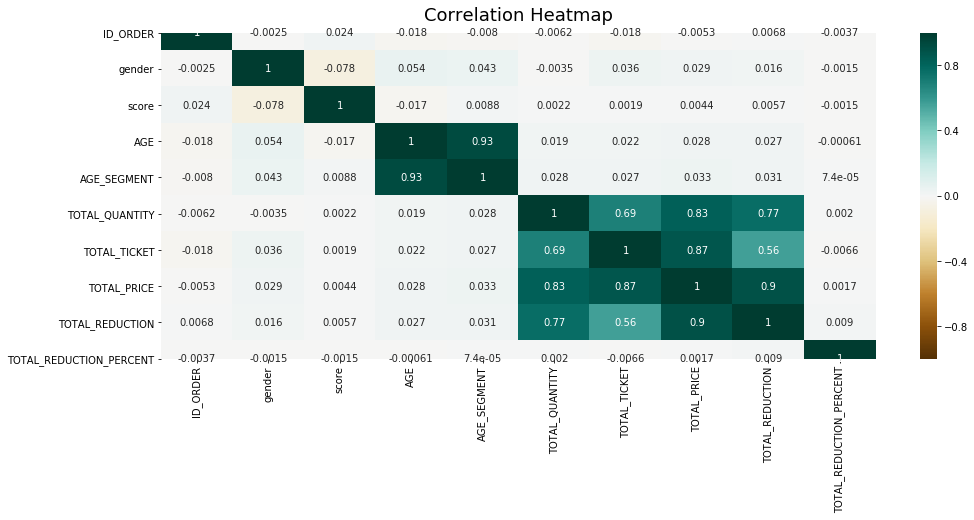

In [127]:
plt.figure(figsize=(16, 6))
heatmap = sns.heatmap(dff.corr(), vmin=-1, vmax=1, annot=True, cmap='BrBG')
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':18}, pad=12)

In [125]:
dff['gender'].replace({'femme': 1},inplace=True)
dff['gender'].replace({'homme': 2},inplace=True)


In [126]:
dff['gender'].value_counts()

1.0    100404
2.0     64922
Name: gender, dtype: int64

In [150]:
dff

,ID_ORDER,DATE-ADD,TIME-ADD,HOUR,SEASON,P_MONTH,P_WEEK,COVID,CONFINEMENT,CURFEW,...,REGION,AREA,CLASS,TOTAL_QUANTITY,TOTAL_QUANTITY_SEGMENTS,TOTAL_TICKET,TICKET_VALUE,TOTAL_PRICE,TOTAL_REDUCTION,TOTAL_REDUCTION_PERCENT
13,15035121,2018-01-01,2018-01-01 17:55:10,Late_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,centre-est,urbaine,C+,3,Entre 3 et 5 Pièces,179.80,Entre 100 et 200 DT,259.7,79.90,30.766269
39,16264861,2018-01-01,2018-01-01 16:37:29,Late_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,centre-est,urbaine,B,1,1 pièce,179.90,Entre 100 et 200 DT,179.9,0.00,0.000000
41,16264868,2018-01-01,2018-01-01 17:32:02,Late_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,centre-est,urbaine,C+,1,1 pièce,99.90,Inférieur à 100 DT,99.9,0.00,0.000000
97,35026888,2018-01-01,2018-01-01 16:03:51,Late_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,centre-ouest,urbaine,C-,3,Entre 3 et 5 Pièces,159.80,Entre 100 et 200 DT,216.7,56.90,26.257499
98,35026890,2018-01-01,2018-01-01 16:07:20,Late_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,centre-ouest,urbaine,C-,2,2 pièces,101.35,Entre 100 et 200 DT,133.8,32.45,24.252616
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86997,670067091,2021-07-04,2021-07-04 11:30:33,Late_morning,Summer,Start_of_Month,Week_End,Post-Covid,NO,de 22h à 5h,...,NaN,NaN,NaN,2,2 pièces,194.60,Entre 100 et 200 DT,278.0,83.40,30.000000
87000,670067090,2021-07-04,2021-07-04 10:49:45,Late_morning,Summer,Start_of_Month,Week_End,Post-Covid,NO,de 22h à 5h,...,NaN,NaN,NaN,1,1 pièce,76.30,Inférieur à 100 DT,109.0,32.70,30.000000
87001,670067095,2021-07-04,2021-07-04 17:56:33,Late_afternoon,Summer,Start_of_Month,Week_End,Post-Covid,NO,de 22h à 5h,...,sud-ouest,urbaine,B,1,1 pièce,76.30,Inférieur à 100 DT,109.0,32.70,30.000000
87008,14156247,2021-07-04,2021-07-04 15:07:42,Late_afternoon,Summer,Start_of_Month,Week_End,Post-Covid,NO,de 22h à 5h,...,nord-est,urbaine,C+,1,1 pièce,19.90,Inférieur à 100 DT,69.9,50.00,71.530758


In [151]:
dff.to_excel(r'C:\Users\sofi\Desktop\dataticket\ticket.xlsx', index = False)

In [152]:
result

,ID_ORDER,DATE-ADD,TIME-ADD,HOUR,SEASON,P_MONTH,P_WEEK,COVID,CONFINEMENT,CURFEW,...,REGION,AREA,CLASS,TOTAL_QUANTITY,TOTAL_QUANTITY_SEGMENTS,TOTAL_TICKET,TICKET_VALUE,TOTAL_PRICE,TOTAL_REDUCTION,TOTAL_REDUCTION_PERCENT
0,66032518,2018-01-01,2018-01-01 12:06:50,Early_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,0,NaN,135.90,Entre 100 et 200 DT,41.0,-94.90,-231.463415
1,80143573,2018-01-01,2018-01-01 16:03:37,Late_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,1,1 pièce,79.90,Inférieur à 100 DT,79.9,0.00,0.000000
2,80143576,2018-01-01,2018-01-01 17:38:26,Late_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,2,2 pièces,124.85,Entre 100 et 200 DT,164.8,39.95,24.241505
3,80143572,2018-01-01,2018-01-01 14:52:08,Early_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,1,1 pièce,49.90,Inférieur à 100 DT,49.9,0.00,0.000000
4,80143574,2018-01-01,2018-01-01 16:56:04,Late_afternoon,Winter,Start_of_Month,Start_of_Week,Pre-Covid,NON,NON,...,Grand-Tunis,urbaine,B,1,1 pièce,59.90,Inférieur à 100 DT,59.9,0.00,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87005,1300225885,2021-07-04,2021-07-04 12:27:16,Early_afternoon,Summer,Start_of_Month,Week_End,Post-Covid,NO,de 22h à 5h,...,NaN,NaN,NaN,3,Entre 3 et 5 Pièces,188.16,Entre 100 et 200 DT,268.8,80.64,30.000000
87006,1300225883,2021-07-04,2021-07-04 11:02:34,Late_morning,Summer,Start_of_Month,Week_End,Post-Covid,NO,de 22h à 5h,...,NaN,NaN,NaN,2,2 pièces,139.23,Entre 100 et 200 DT,198.9,59.67,30.000000
87007,1300225886,2021-07-04,2021-07-04 14:34:13,Early_afternoon,Summer,Start_of_Month,Week_End,Post-Covid,NO,de 22h à 5h,...,NaN,NaN,NaN,2,2 pièces,145.53,Entre 100 et 200 DT,207.9,62.37,30.000000
87008,14156247,2021-07-04,2021-07-04 15:07:42,Late_afternoon,Summer,Start_of_Month,Week_End,Post-Covid,NO,de 22h à 5h,...,nord-est,urbaine,C+,1,1 pièce,19.90,Inférieur à 100 DT,69.9,50.00,71.530758


In [153]:
result.to_excel(r'C:\Users\sofi\Desktop\dataticket\tickeet.xlsx', index = False)